# HydroSense-Kenya: Scientific Computing for Smart Irrigation
## Milestone 5: Differential Equations, Monte Carlo, and Optimization
#### 1. Differential Equations for Soil Moisture
---
To predict future water states, we model soil moisture as an Ordinary Differential Equation (ODE). We compare the computationally cheap Euler Method against the highly stable Runge-Kutta 4th Order (RK4) method.

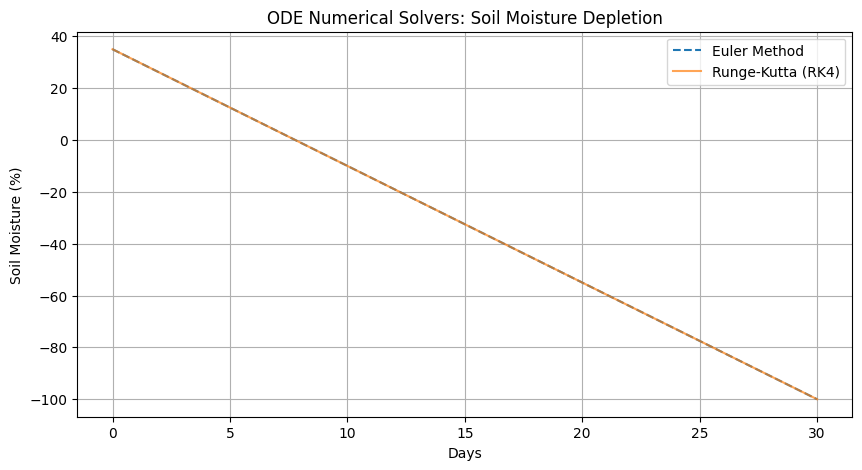

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))
from simulation import euler_method, runge_kutta_4, generate_monte_carlo_rainfall
from optimization import optimize_irrigation_schedule

# Mocking initial environmental data for simulation (derived from previous levels)
days = 30
R_arr = np.zeros(days) 
I_arr = np.zeros(days)
ET_arr = np.full(days, 4.5) 
S0 = 35.0
FC = 41.0
D_coeff = 0.18

euler_res = euler_method(S0, R_arr, I_arr, ET_arr, FC, D_coeff, days)
rk4_res = runge_kutta_4(S0, R_arr, I_arr, ET_arr, FC, D_coeff, days)

plt.figure(figsize=(10, 5))
plt.plot(euler_res, label='Euler Method', linestyle='--')
plt.plot(rk4_res, label='Runge-Kutta (RK4)', alpha=0.7)
plt.title('ODE Numerical Solvers: Soil Moisture Depletion')
plt.ylabel('Soil Moisture (%)')
plt.xlabel('Days')
plt.legend()
plt.grid(True)
plt.show()

## Monte Carlo Simulation 
#### 2. Monte Carlo Uncertainty Analysis using stochastic modelling:
---
 We generate 1,000 distinct rainfall scenarios based on historical variance. This allows us to calculate specific risk probabilities regarding water scarcity.  

In [5]:
# Generate 1,000 rainfall scenarios (Mean = 2.0mm, Std = 5.0mm)
mc_scenarios = generate_monte_carlo_rainfall(mean_rain=2.0, std_rain=5.0, days=30, iterations=1000)

shortage_count = 0
over_irrigation_count = 0
total_demand = []

min_moisture = 22.0

for i in range(1000):
    scenario_rain = mc_scenarios[i]
    sim_S = runge_kutta_4(S0, scenario_rain, np.zeros(days), ET_arr, FC, D_coeff, days)
    
    if np.any(sim_S < min_moisture):
        shortage_count += 1
    if np.any(sim_S > FC):
        over_irrigation_count += 1
        
    demand = np.sum(np.maximum(0, min_moisture - sim_S[:-1]))
    total_demand.append(demand)

prob_shortage = (shortage_count / 1000) * 100
prob_over = (over_irrigation_count / 1000) * 100
expected_demand = np.mean(total_demand)
worst_case = np.max(total_demand)

print(f"--- Monte Carlo Risk Probabilities (1,000 Iterations) ---")
print(f"Probability of Water Shortage: {prob_shortage}%")
print(f"Probability of Over-Saturation: {prob_over}%")
print(f"Expected Irrigation Demand: {expected_demand:.2f} mm")
print(f"Worst-Case Scenario Demand: {worst_case:.2f} mm")

--- Monte Carlo Risk Probabilities (1,000 Iterations) ---
Probability of Water Shortage: 97.5%
Probability of Over-Saturation: 22.5%
Expected Irrigation Demand: 318.51 mm
Worst-Case Scenario Demand: 1028.37 mm


## Optimization and Trade-offs
#### 3. Irrigation Optimization and Trade-offs
---
We apply a forward-looking heuristic algorithm to minimize water use. The system only triggers the pumps when the projected moisture drops below the critical minimum, applying just enough water to reach the target.

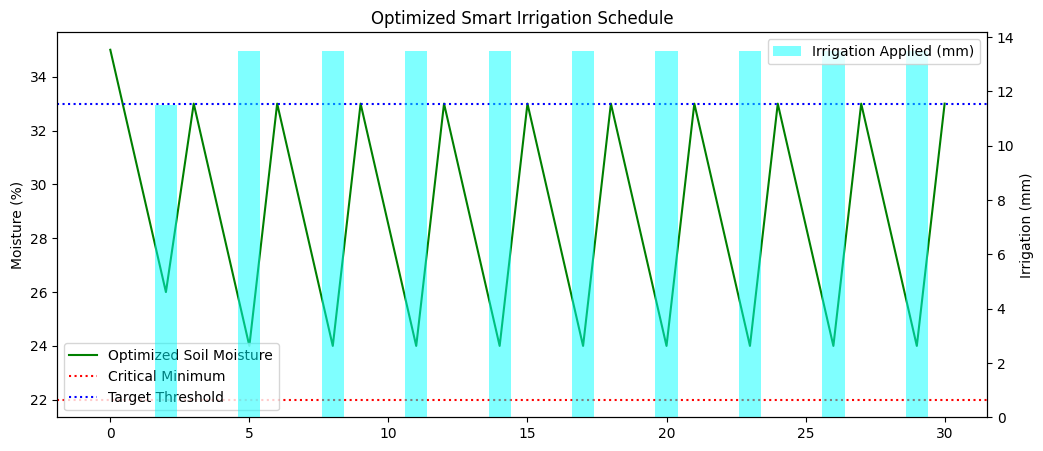

Total Optimized Water Prescribed: 133.00 mm


In [6]:
target_moisture = 33.0

opt_irrigation, opt_S = optimize_irrigation_schedule(
    S0, np.zeros(days), ET_arr, min_moisture, target_moisture, FC, D_coeff, days
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(opt_S, color='green', label='Optimized Soil Moisture')
ax1.axhline(min_moisture, color='red', linestyle=':', label='Critical Minimum')
ax1.axhline(target_moisture, color='blue', linestyle=':', label='Target Threshold')

ax2.bar(range(days), opt_irrigation, color='cyan', alpha=0.5, label='Irrigation Applied (mm)')

ax1.set_ylabel('Moisture (%)')
ax2.set_ylabel('Irrigation (mm)')
plt.title('Optimized Smart Irrigation Schedule')
ax1.legend(loc='lower left')
ax2.legend(loc='upper right')
plt.show()

print(f"Total Optimized Water Prescribed: {np.sum(opt_irrigation):.2f} mm")

## Scientific Interpretation
#### 4. Scientific Trade-offs
---
##### Water Conservation vs. Crop Stress: 
The optimizer adopts a "just-in-time" approach, leaving the soil moisture very close to the minimum threshold for extended periods. While this maximizes water conservation, it leaves a razor-thin margin for error. A sudden temperature spike could plunge the crops into fatal water stress before the pumps engage.
Pump Energy Demand: The algorithm applies large pulses of water infrequently rather than small trickles daily. This reduces the mechanical wear and start/stop electrical surges of the pumps, optimizing energy use at the cost of short-term moisture volatility in the root zone.